# Bridge Analysis — `climate_19.graphml`

Questo notebook:
- classifica ogni arco del network come **bridge** (A–B) o **internal** (A–A / B–B)
- classifica la tipologia dei bridge (core-core, periferia-periferia, core-perifera)
- calcola la **neighborhood overlap** seguendo la definizione:

$$O_{AB} = \frac{|N(A) \cap N(B)|}{|N(A) \cup N(B)|}$$

- $O_{AB} = 0$ → **local bridge** (nessun vicino in comune)
- Overlap basso → legame debole tra comunità distanti


In [2]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

G = nx.read_graphml(r"C:\Users\maria\Desktop\Analisi e visualizzazione reti complesse\AVRC_FinnishTwittersphereProject\Data\climate_19.graphml")

groups    = nx.get_node_attributes(G, 'group')      # 'A' o 'B'
hierarchy = nx.get_node_attributes(G, 'hierarchy')  # 'A_CORE', 'B_PERIPHERY', ...

#print(f"Nodi : {G.number_of_nodes()}")
#print(f"Archi: {G.number_of_edges()}")
#print("Distribuzione gruppi:", Counter(groups.values()))


In [3]:
def neighborhood_overlap(G, u, v):
    """
    Neighborhood overlap dell'arco (u, v).
    O_AB = |N(A) ∩ N(B)| / |N(A) ∪ N(B)|   [NS04]
    u e v sono esclusi da entrambi gli insiemi.
    """
    neighbors_u = set(G.neighbors(u)) - {v}
    neighbors_v = set(G.neighbors(v)) - {u}
    common = neighbors_u & neighbors_v
    union  = neighbors_u | neighbors_v
    return len(common) / len(union) if union else 0.0




## 3. Calcolo overlap e classificazione degli archi

In [4]:
rows = []
for u, v in G.edges():
    g_u = groups.get(u, '?')
    g_v = groups.get(v, '?')
    overlap = neighborhood_overlap(G, u, v)

    rows.append({
        'node_u'         : u,
        'node_v'         : v,
        'group_u'        : g_u,
        'group_v'        : g_v,
        'hierarchy_u'    : hierarchy.get(u, '?'),
        'hierarchy_v'    : hierarchy.get(v, '?'),
        'edge_type'      : 'bridge' if g_u != g_v else 'internal',
        'overlap'        : overlap,
        'is_local_bridge': overlap == 0.0,
    })

df = pd.DataFrame(rows)
print(f"Archi totali: {len(df)}")
df.head()


Archi totali: 50605


,node_u,node_v,group_u,group_v,hierarchy_u,hierarchy_v,edge_type,overlap,is_local_bridge
0,22923,42042,A,A,A_PERIPHERY,A_CORE,internal,0.051471,False
1,22923,31998,A,A,A_PERIPHERY,A_CORE,internal,0.007752,False
2,22923,13449,A,A,A_PERIPHERY,A_CORE,internal,0.012324,False
3,22923,24446,A,A,A_PERIPHERY,A_CORE,internal,0.014706,False
4,22923,31993,A,A,A_PERIPHERY,A_CORE,internal,0.010969,False


## 4. Statistiche di sintesi

In [5]:
print("====== Distribuzione tipi di arco (link ponte o interni alle comunità) ===")
print(df['edge_type'].value_counts())

print("\n========= Overlap per tipo ===")
print(df.groupby('edge_type')['overlap'].describe().round(4))

print("\n========= Local bridges (overlap = 0) per tipo ===")
print(df[df['is_local_bridge']]['edge_type'].value_counts())

# Local bridges interni per comunità
print("\n========= Local bridges (overlap = 0) per comunità ===")
lb_internal = df[(df['is_local_bridge']) & (df['edge_type'] == 'internal')]
print(lb_internal['group_u'].value_counts().rename('local bridges internal per comunità'))


print("\n=== Tipologia dei bridge (core-core, core-periferia, periferia-periferia)===")
def bridge_role(h_u, h_v):
    """Classifica un bridge in base alla gerarchia dei due estremi."""
    is_core_u = 'CORE' in str(h_u)
    is_core_v = 'CORE' in str(h_v)
    cores = is_core_u + is_core_v
    if cores == 2:
        return 'Core–Core'
    elif cores == 1:
        return 'Core–Periphery'
    else:
        return 'Periphery–Periphery'

# Applica solo agli archi bridge
bridges_df = df[df['edge_type'] == 'bridge'].copy()
bridges_df['bridge_role'] = bridges_df.apply(
    lambda r: bridge_role(r['hierarchy_u'], r['hierarchy_v']), axis=1
)

# Conteggi e percentuali
role_counts = bridges_df['bridge_role'].value_counts()
role_pct    = (role_counts / len(bridges_df) * 100).round(1)
print(pd.DataFrame({'count': role_counts, 'pct (%)': role_pct}))

# Overlap medio per tipologia
print("\n========= Overlap medio per tipologia ===")
print(bridges_df.groupby('bridge_role')['overlap'].describe().round(4))

# Local bridges per tipologia
print("\n========= Local bridges (overlap = 0) per tipologia ===")
print(bridges_df[bridges_df['is_local_bridge']]['bridge_role'].value_counts())

# Dettaglio Core–Periphery: quale comunità ha il core e quale la periferia?
cp_df = bridges_df[bridges_df['bridge_role'] == 'Core–Periphery'].copy()

def cp_direction(row):
    if 'CORE' in row['hierarchy_u']:
        return f"{row['group_u']}_Core → {row['group_v']}_Periphery"
    else:
        return f"{row['group_v']}_Core → {row['group_u']}_Periphery"

cp_df['direction'] = cp_df.apply(cp_direction, axis=1)

print("========= Core–Periphery: direzione del bridge ===")
dir_counts = cp_df['direction'].value_counts()
dir_pct    = (dir_counts / len(cp_df) * 100).round(1)
print(pd.DataFrame({'count': dir_counts, 'pct (%)': dir_pct}))


====== Distribuzione tipi di arco (link ponte o interni alle comunità) ===
edge_type
internal    45871
bridge       4734
Name: count, dtype: int64

========= Overlap per tipo ===
             count    mean     std  min  25%     50%     75%     max
edge_type                                                           
bridge      4734.0  0.0113  0.0216  0.0  0.0  0.0000  0.0145  0.2941
internal   45871.0  0.0255  0.0428  0.0  0.0  0.0066  0.0357  1.0000

========= Local bridges (overlap = 0) per tipo ===
edge_type
internal    19772
bridge       2430
Name: count, dtype: int64

========= Local bridges (overlap = 0) per comunità ===
group_u
B    11446
A     8326
Name: local bridges internal per comunità, dtype: int64

=== Tipologia dei bridge (core-core, core-periferia, periferia-periferia)===
                     count  pct (%)
bridge_role                        
Core–Periphery        2773     58.6
Core–Core             1097     23.2
Periphery–Periphery    864     18.3

========= Overlap me

C:\Users\giuli\AppData\Local\Temp\ipykernel_18368\1875996216.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp   = axes[1].boxplot(data, labels=roles, patch_artist=True,


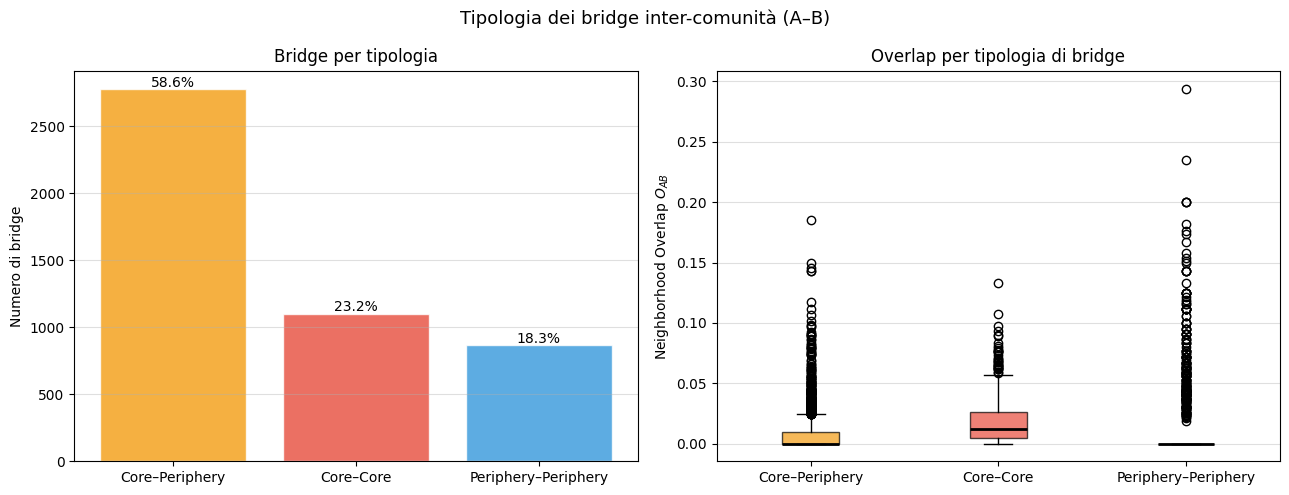

In [6]:

# Grafico
colors = {'Core–Core': '#e74c3c', 'Core–Periphery': '#f39c12', 'Periphery–Periphery': '#3498db'}
roles  = list(role_counts.index)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bar_colors = [colors[r] for r in roles]
axes[0].bar(roles, role_counts.values, color=bar_colors, alpha=0.8, edgecolor='white')
for i, (cnt, pct) in enumerate(zip(role_counts.values, role_pct.values)):
    axes[0].text(i, cnt + 20, f"{pct}%", ha='center', fontsize=10)
axes[0].set_ylabel("Numero di bridge")
axes[0].set_title("Bridge per tipologia")
axes[0].grid(axis='y', alpha=0.4)

data = [bridges_df[bridges_df['bridge_role'] == r]['overlap'].values for r in roles]
bp   = axes[1].boxplot(data, labels=roles, patch_artist=True,
                       medianprops=dict(color='black', linewidth=2))
for patch, r in zip(bp['boxes'], roles):
    patch.set_facecolor(colors[r]); patch.set_alpha(0.7)
axes[1].set_ylabel("Neighborhood Overlap $O_{AB}$")
axes[1].set_title("Overlap per tipologia di bridge")
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle("Tipologia dei bridge inter-comunità (A–B)", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Visualizzazione

Confronto della distribuzione di overlap tra archi **bridge** (inter-comunità)
e **internal** (intra-comunità).


C:\Users\giuli\AppData\Local\Temp\ipykernel_18368\1317714974.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(


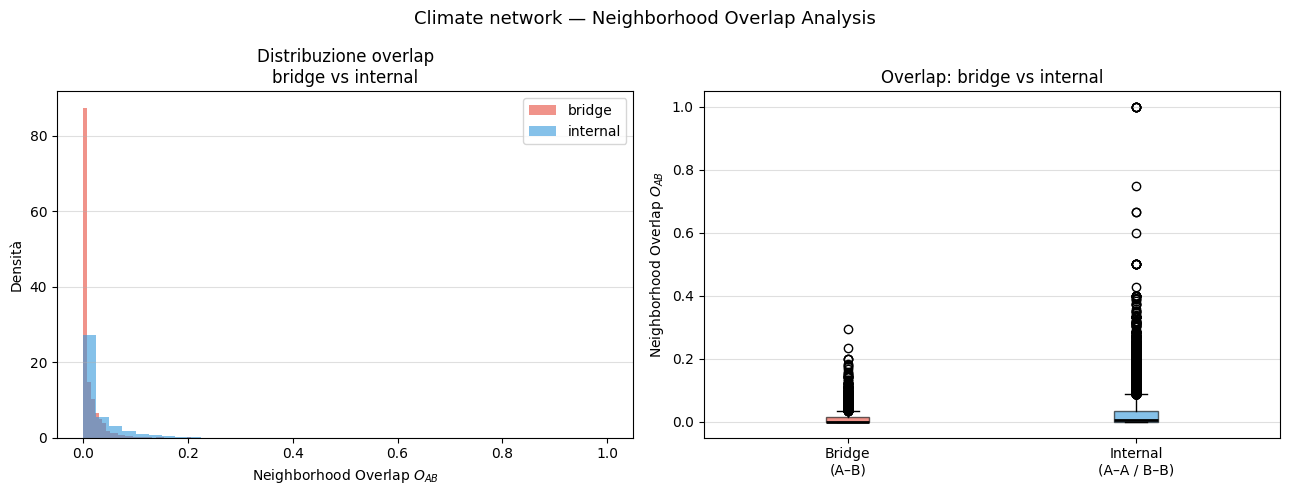

Plot salvato: climate_overlap_plot.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Istogramma
for etype, color in [('bridge', '#e74c3c'), ('internal', '#3498db')]:
    subset = df[df['edge_type'] == etype]['overlap']
    axes[0].hist(subset, bins=40, alpha=0.6, label=etype, color=color, density=True)
axes[0].set_xlabel("Neighborhood Overlap $O_{AB}$")
axes[0].set_ylabel("Densità")
axes[0].set_title("Distribuzione overlap\nbridge vs internal")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.4)

# Boxplot
bp = axes[1].boxplot(
    [df[df['edge_type']=='bridge']['overlap'].values,
     df[df['edge_type']=='internal']['overlap'].values],
    labels=['Bridge\n(A–B)', 'Internal\n(A–A / B–B)'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
)
bp['boxes'][0].set_facecolor('#e74c3c'); bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#3498db'); bp['boxes'][1].set_alpha(0.6)
axes[1].set_ylabel("Neighborhood Overlap $O_{AB}$")
axes[1].set_title("Overlap: bridge vs internal")
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle("Climate network — Neighborhood Overlap Analysis", fontsize=13)
plt.tight_layout()
plt.savefig("climate_overlap_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot salvato: climate_overlap_plot.png")


# EI index

In [8]:
# EI Index per nodo
# EI = (E - I) / (E + I)
# E = archi esterni (verso l'altra comunità), I = archi interni (stessa comunità)
# EI = +1 → nodo completamente rivolto verso l'esterno
# EI = -1 → nodo completamente rivolto verso l'interno

ei_rows = []
for node in G.nodes():
    g = groups.get(node, '?')
    neighbors = list(G.neighbors(node))
    E = sum(1 for n in neighbors if groups.get(n) != g)
    I = sum(1 for n in neighbors if groups.get(n) == g)
    ei = (E - I) / (E + I) if (E + I) > 0 else 0.0
    ei_rows.append({'node': node, 'group': g, 'hierarchy': hierarchy.get(node, '?'),
                    'E': E, 'I': I, 'ei_index': ei})

df_ei = pd.DataFrame(ei_rows)

print("=== EI Index medio per gruppo ===")
print(df_ei.groupby('group')['ei_index'].describe().round(4))

print("\n=== EI Index medio per gerarchia ===")
print(df_ei.groupby('hierarchy')['ei_index'].describe().round(4))

print("\n=== Top 10 nodi più 'bridge' (EI più alto) ===")
print(df_ei.sort_values('ei_index', ascending=False).head(10).to_string(index=False))

=== EI Index medio per gruppo ===
        count    mean     std  min  25%  50%  75%     max
group                                                    
A      7409.0 -0.9329  0.1762 -1.0 -1.0 -1.0 -1.0  0.0667
B      9230.0 -0.8653  0.2996 -1.0 -1.0 -1.0 -1.0  0.0000

=== EI Index medio per gerarchia ===
              count    mean     std  min     25%     50%     75%     max
hierarchy                                                               
A_CORE        362.0 -0.8631  0.1495 -1.0 -0.9615 -0.9078 -0.8125 -0.2000
A_PERIPHERY  7047.0 -0.9365  0.1768 -1.0 -1.0000 -1.0000 -1.0000  0.0667
B_CORE        458.0 -0.7759  0.2416 -1.0 -1.0000 -0.8640 -0.6488  0.0000
B_PERIPHERY  8772.0 -0.8700  0.3016 -1.0 -1.0000 -1.0000 -1.0000  0.0000

=== Top 10 nodi più 'bridge' (EI più alto) ===
 node group   hierarchy  E  I  ei_index
 4914     A A_PERIPHERY  8  7  0.066667
18252     B B_PERIPHERY  3  3  0.000000
34960     B B_PERIPHERY  1  1  0.000000
33331     B B_PERIPHERY  1  1  0.000000
34928     

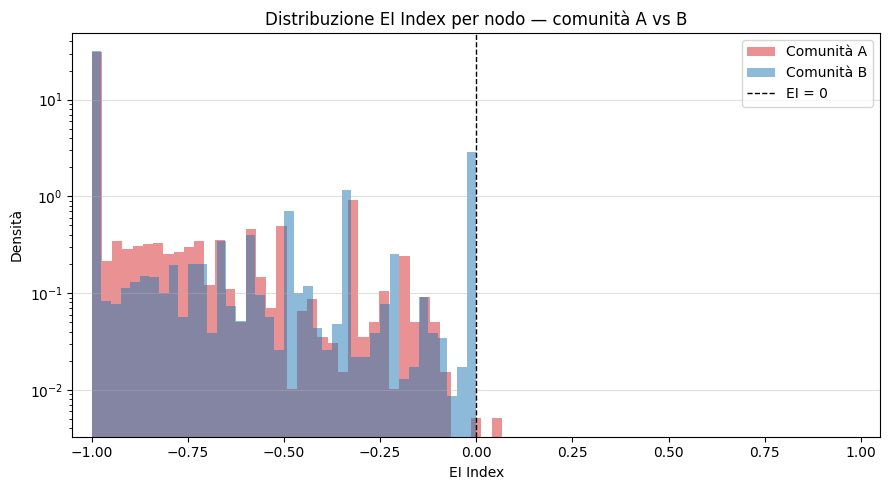

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

cmap = plt.get_cmap('tab10')

for group, color in [('A', cmap(3)), ('B', cmap(0))]:
    subset = df_ei[df_ei['group'] == group]['ei_index']
    ax.hist(subset, bins=40, alpha=0.5, density=True, color=color, label=f"Comunità {group}")

ax.axvline(0, color='black', linestyle='--', linewidth=1, label='EI = 0')
ax.set_xlabel("EI Index")
ax.set_ylabel("Densità")
ax.set_xlim(-1.05, 1.05)
ax.set_yscale('log')
ax.set_title("Distribuzione EI Index per nodo — comunità A vs B")
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

## 6. Local bridges e Structural Holes

Un nodo che incide su molti local bridges occupa uno **structural hole**:
si trova tra gruppi che non interagirebbero altrimenti (Burt, 2000).


In [7]:
lb_edges = [(r['node_u'], r['node_v'])
            for _, r in df[df['is_local_bridge']].iterrows()]

hole_count = defaultdict(int)
for u, v in lb_edges:
    hole_count[u] += 1
    hole_count[v] += 1

df_holes = pd.DataFrame([
    {'node': n, 'structural_holes': cnt,
     'degree': G.degree(n),
     'group': groups.get(n, '?'),
     'hierarchy': hierarchy.get(n, '?')}
    for n, cnt in hole_count.items()
]).sort_values('structural_holes', ascending=False)

print("Top 10 nodi per structural hole access:")
df_holes.head(10)


Top 10 nodi per structural hole access:


,node,structural_holes,degree,group,hierarchy
7881,18407,1074,1139,B,B_CORE
799,13449,268,1124,A,A_CORE
431,34919,224,315,A,A_CORE
1444,4709,215,430,A,A_CORE
482,31993,214,1080,A,A_CORE
4011,5090,187,243,B,B_CORE
2214,11414,157,227,B,B_CORE
3061,34187,152,155,B,B_CORE
800,1991,149,782,A,A_CORE
440,8074,144,196,A,A_CORE


## 7. Export dei risultati

In [13]:
df.to_csv("climate_overlap_results.csv", index=False)
#df_holes.to_csv("climate_structural_holes.csv", index=False)

print("File salvati:")
print("  climate_overlap_results.csv   — archi con overlap e tipo")
#print("  climate_structural_holes.csv  — nodi ordinati per structural hole access")


File salvati:
  climate_overlap_results.csv   — archi con overlap e tipo
